<i>Copyright (c) Recommenders contributors.</i>

<i>Licensed under the MIT License.</i>

# Sequential Recommender Quick Start

### Example: SLi_Rec : Adaptive User Modeling with Long and Short-Term Preferences for Personailzed Recommendation
Unlike a general recommender such as Matrix Factorization or xDeepFM (in the repo) which doesn't consider the order of the user's activities, sequential recommender systems take the sequence of the user behaviors as context and the goal is to predict the items that the user will interact in a short time (in an extreme case, the item that the user will interact next).

This notebook aims to give you a quick example of how to train a sequential model based on a public Amazon dataset. Currently, we can support NextItNet \[4\], GRU \[2\], Caser \[3\], A2SVD \[1\], SLi_Rec \[1\], and SUM \[5\]. Without loss of generality, this notebook takes [SLi_Rec model](https://www.microsoft.com/en-us/research/uploads/prod/2019/07/IJCAI19-ready_v1.pdf) for example.
SLi_Rec \[1\] is a deep learning-based model aims at capturing both long and short-term user preferences for precise recommender systems. To summarize, SLi_Rec has the following key properties:

* It adopts the attentive "Asymmetric-SVD" paradigm for long-term modeling;
* It takes both time irregularity and semantic irregularity into consideration by modifying the gating logic in LSTM.
* It uses an attention mechanism to dynamic fuse the long-term component and short-term component.

In this notebook, we test SLi_Rec on a subset of the public dataset: [Amazon_reviews](http://snap.stanford.edu/data/amazon/productGraph/categoryFiles/reviews_Movies_and_TV_5.json.gz) and [Amazon_metadata](http://snap.stanford.edu/data/amazon/productGraph/categoryFiles/meta_Movies_and_TV.json.gz)

This notebook is tested under TF 2.6. 

## 0. Global Settings and Imports

In [18]:
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


import tensorflow.compat.v1 as tf
tf.get_logger().setLevel('ERROR') # only show error messages

from sklearn.metrics import roc_auc_score
from scipy.special import softmax

from recommenders.utils.timer import Timer
from recommenders.utils.constants import SEED
from recommenders.models.deeprec.deeprec_utils import (
    prepare_hparams
)
from recommenders.datasets.amazon_reviews import data_preprocessing
from recommenders.models.deeprec.models.sequential.sli_rec import SLI_RECModel as SeqModel
from recommenders.models.deeprec.io.sequential_iterator import SequentialIterator
from recommenders.utils.notebook_utils import store_metadata



print(f"System version: {sys.version}")
print(f"Tensorflow version: {tf.__version__}")

print("CWD:", os.getcwd())



System version: 3.9.21 | packaged by conda-forge | (main, Dec  5 2024, 13:47:18) 
[Clang 18.1.8 ]
Tensorflow version: 2.15.0
CWD: /Users/diegorodriguezescalona/Documents/Duke/Classes/2-Spring_2025/Principles_ML/Context-Aware-Recommendation-Systems/Experiments/increase_diversity_in_rec


#### Parameters

In [19]:
EPOCHS = 10
BATCH_SIZE = 400
RANDOM_SEED = SEED  # Set None for non-deterministic result

data_path = os.path.join("..", "..", "Data", "increase_diversity_in_rec")

##  ATTENTION: change to the corresponding config file, e.g., caser.yaml for CaserModel, sum.yaml for SUMModel
yaml_file = '/Users/diegorodriguezescalona/Documents/Duke/Classes/2-Spring_2025/Principles_ML/Context-Aware-Recommendation-Systems/Experiments/increase_diversity_in_rec/recommenders/models/deeprec/config/sli_rec.yaml'  

##  1. Input data format

###  1.1 Amazon dataset
The input data contains 8 columns, i.e.,   `<label> <user_id> <item_id> <category_id> <timestamp> <history_item_ids> <history_cateory_ids> <hitory_timestamp>`  columns are seperated by `"\t"`.  item_id and category_id denote the target item and category, which means that for this instance, we want to guess whether user user_id will interact with item_id at timestamp. `<history_*>` columns record the user behavior list up to `<timestamp>`, elements are separated by commas.  `<label>` is a binary value with 1 for positive instances and 0 for negative instances.  One example for an instance is: 

`1       A1QQ86H5M2LVW2  B0059XTU1S      Movies  1377561600      B002ZG97WE,B004IK30PA,B000BNX3AU,B0017ANB08,B005LAIHW2  Movies,Movies,Movies,Movies,Movies   1304294400,1304812800,1315785600,1316304000,1356998400` 

In data preprocessing stage, we have a script to generate some ID mapping dictionaries, so user_id, item_id and category_id will be mapped into interager index starting from 1. And you need to tell the input iterator where is the ID mapping files are. (For example, in the next section, we have some mapping files like user_vocab, item_vocab, and cate_vocab).  The data preprocessing script is at [recommenders/dataset/amazon_reviews.py](../../recommenders/dataset/amazon_reviews.py), you need to call the `_create_vocab(train_file, user_vocab, item_vocab, cate_vocab)` function. Note that ID vocabulary only creates from the train_file, so the new IDs in valid_file or test_file will be regarded as unknown IDs and assigned with a defualt 0 index.

### 1.2  Negative intances
We use Softmax to the loss function. In training and evalution stage, we group 1 positive instance with `num_ngs` negative instances. Pair-wise ranking can be regarded as a special case of softmax ranking, where `num_ngs` is set to 1. 

More specifically, for training and evalation, you need to organize the data file such that each one positive instance is followed by `num_ngs` negative instances. Our program will take `1+num_ngs` lines as a unit for Softmax calculation. `num_ngs` is a parameter you need to pass to the `prepare_hparams`, `fit` and `run_eval` function. `train_num_ngs` in `prepare_hparams` denotes the number of negative instances for training, where a recommended number is 4. `valid_num_ngs` and `num_ngs` in `fit` and `run_eval` denote the number in evalution. In evaluation, the model calculates metrics among the `1+num_ngs` instances. For the `predict` function, since we only need to calcuate a score for each individual instance, there is no need for `num_ngs` setting.  More details and examples will be provided in the following sections.

For training stage, if you don't want to prepare negative instances, you can just provide positive instances and set the parameter `need_sample=True, train_num_ngs=train_num_ngs` for function `prepare_hparams`, our model will dynamicly sample `train_num_ngs` instances as negative samples in each mini batch.

In [20]:

# for test
train_file = os.path.join(data_path, r'train_data')
valid_file = os.path.join(data_path, r'valid_data')
test_file = os.path.join(data_path, r'test_data')
user_vocab = os.path.join(data_path, r'user_vocab.pkl')
item_vocab = os.path.join(data_path, r'item_vocab.pkl')
cate_vocab = os.path.join(data_path, r'category_vocab.pkl')
output_file = os.path.join(data_path, r'output.txt')

reviews_name = 'reviews_Movies_and_TV_5.json'
meta_name = 'meta_Movies_and_TV.jsonl'
reviews_file = os.path.join(data_path, reviews_name)
meta_file = os.path.join(data_path, meta_name)
train_num_ngs = 4 # number of negative instances with a positive instance for training
valid_num_ngs = 4 # number of negative instances with a positive instance for validation
test_num_ngs = 9 # number of negative instances with a positive instance for testing
sample_rate = 1 # sample a small item set for training and testing here for fast example (it goes between 0 and )

input_files = [reviews_file, meta_file, train_file, valid_file, test_file, user_vocab, item_vocab, cate_vocab]

#Create the data that feeds into the model. 
#data_preprocessing(*input_files, sample_rate=sample_rate, valid_num_ngs=valid_num_ngs, test_num_ngs=test_num_ngs)


#### 1.1 Prepare hyper-parameters
`prepare_hparams()` will create a full set of hyper-parameters for model training, such as learning rate, feature number, and dropout ratio. We can put those parameters in a yaml file (a complete list of parameters can be found under our config folder) , or pass parameters as the function's parameters (which will overwrite yaml settings).


In [21]:
### NOTE:  
hparams = prepare_hparams(
    yaml_file,                  # YAML file for model hyper-parameters
    embed_l2=0.,                # L2 regularization strength for embedding matrices (overrides YAML)
    layer_l2=0.,                # L2 regularization strength for DNN / RNN layer weights
    learning_rate=0.001,        # Optimizer learning rate (use 0.01 if batch-norm is OFF)
    epochs=EPOCHS,              # Total number of training epochs
    batch_size=BATCH_SIZE,      # Mini-batch size; must be multiple of (1 + train_num_ngs) when sampling
    show_step=50,               # Log metrics every `show_step` mini-batches
    MODEL_DIR=os.path.join(data_path, "model/"),       # Directory to save model checkpoints
    SUMMARIES_DIR=os.path.join(data_path, "summary/"), # Directory for TensorBoard event files
    user_vocab=user_vocab,      # Pickle file mapping user IDs → indices
    item_vocab=item_vocab,      # Pickle file mapping item IDs → indices
    cate_vocab=cate_vocab,      # Pickle file mapping category IDs → indices
    need_sample=True,           # Enable dynamic negative sampling during training
    train_num_ngs=train_num_ngs # Number of negative samples generated per positive instance
)

#### 1.2 Create data loader
Designate a data iterator for the model. All our sequential models use SequentialIterator. 
data format is introduced aboved. 

<br>Validation and testing data are files after negative sampling offline with the number of `<num_ngs>` and `<test_num_ngs>`.

In [5]:
#input_creator = SequentialIterator
#### uncomment this for the NextItNet model, because it needs a special data iterator for training
#input_creator = NextItNetIterator

## 2. Create model
When both hyper-parameters and data iterator are ready, we can create a model:

In [6]:
#Define a model instance (uncomment to train a model)
#model = SeqModel(hparams, input_creator, seed=RANDOM_SEED)

Now let's see what is the model's performance at this point (without starting training):

In [7]:
# test the model before training (uncomment to test a model)
#print(model.run_eval(test_file, num_ngs=test_num_ngs)) 

AUC=0.5 is a state of random guess. We can see that before training, the model behaves like random guessing.

#### 2.1 Train model
Next we want to train the model on a training set, and check the performance on a validation dataset. Training the model is as simple as a function call:

In [8]:
#train the model (uncomment to train a model)
# with Timer() as train_time:
#     model = model.fit(train_file, valid_file, valid_num_ngs=valid_num_ngs) 

# print('Time cost for training is {0:.2f} mins'.format(train_time.interval/60.0))

#### 2.2  Evaluate model

Again, let's see what is the model's performance now (after training):

In [9]:
#res_syn = model.run_eval(test_file, num_ngs=test_num_ngs)
#print(res_syn)


In [10]:
# # Record results for tests - ignore this cell
# store_metadata("auc", res_syn["auc"])
# store_metadata("logloss", res_syn["logloss"])
# store_metadata("mean_mrr", res_syn["mean_mrr"])
# store_metadata("ndcg@2", res_syn["ndcg@2"])
# store_metadata("ndcg@4", res_syn["ndcg@4"])
# store_metadata("ndcg@6", res_syn["ndcg@6"])
# store_metadata("group_auc", res_syn["group_auc"])


If we want to get the full prediction scores rather than evaluation metrics, we can do this:

## 3. Loading Trained Models
In this section, we provide a simple example to illustrate how we can use the trained model to serve for production demand.

Suppose we are in a new session. First let's load a previous trained model:

In [11]:
input_creator = SequentialIterator
model_best_trained = SeqModel(hparams, input_creator, seed=RANDOM_SEED)
path_best_trained = os.path.join(hparams.MODEL_DIR, "best_model")
print('loading saved model in {0}'.format(path_best_trained))
model_best_trained.load_model(path_best_trained)


2025-04-28 17:51:53.910909: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:388] MLIR V1 optimization pass is not enabled


loading saved model in ../../Data/increase_diversity_in_rec/model/best_model


### 3.1 Sigmoid results of the model for a given user

In the next step, we will make predictions using a serving model. Then we can check if the two result files are consistent.

In [12]:
# build the model object
model_best_trained = SeqModel(hparams, SequentialIterator, seed=RANDOM_SEED)

# restore weights into the *model’s own* session
checkpoint = os.path.join(hparams.MODEL_DIR, "best_model")
model_best_trained.load_model(checkpoint)      # uses model_best_trained.sess

# use that same session
sess         = model_best_trained.sess
pred_tensor  = model_best_trained.pred        # already sigmoid/softmax

test_file = os.path.join(data_path, "test_data_small")
model_best_trained.iterator.batch_size = 10
i = 0
all_probs = []
for batch in model_best_trained.iterator.load_data_from_file(test_file, 0):
    feed_dict = {
        model_best_trained.layer_keeps: [1.0, 1.0],
        model_best_trained.is_train_stage: False,
        model_best_trained.temperature: 1,
        **batch
    }
    probs = sess.run(pred_tensor, feed_dict=feed_dict).flatten()
    all_probs.extend(probs)
    i += 1
    print(probs)
    if i == 1:
        break


[0.58009297 0.53379977 0.6000217  0.6065694  0.6024022  0.55666125
 0.56990075 0.561525   0.60224706 0.5417012 ]


In [13]:
# test_file = os.path.join(data_path, r'test_data')
# # build the model object
# model_best_trained = SeqModel(hparams, SequentialIterator, seed=RANDOM_SEED)

# # restore weights into the *model’s own* session
# checkpoint = os.path.join(hparams.MODEL_DIR, "best_model")
# model_best_trained.load_model(checkpoint)      # uses model_best_trained.sess

# # use that same session
# sess         = model_best_trained.sess
# pred_tensor  = model_best_trained.pred        # already sigmoid/softmax

# test_file = os.path.join(data_path, "test_data")
# model_best_trained.iterator.batch_size = 10

# all_probs = []
# for batch in model_best_trained.iterator.load_data_from_file(test_file, 0):
#     feed_dict = {
#         model_best_trained.layer_keeps: [1.0, 1.0],
#         model_best_trained.is_train_stage: False,
#         model_best_trained.temperature: 1,
#         **batch
#     }
#     probs = sess.run(pred_tensor, feed_dict=feed_dict).flatten()
#     all_probs.extend(probs)

# # 1.  Read the first column (labels) from the TSV file
# test_df  = pd.read_csv(test_file, sep='\t', header=None, usecols=[0])
# y_true   = test_df.iloc[:, 0].to_numpy()

# # 2.  Get model probabilities (your loop already does that)
# y_score  = np.asarray(all_probs)[:len(y_true)]   # trim just in case

# # 3.  AUC
# auc_val  = roc_auc_score(y_true, y_score)
# print("ROC-AUC:", auc_val)

In [14]:
test_file = os.path.join(data_path, "test_data_mid")
model_best_trained.iterator.batch_size = 10
group_size = 10
temperatures = [0.0001, 0.001, 0.01, 0.1, 0.5, 1, 2, 5, 10]

# Ground-truth labels (first column of the TSV)
y_true = pd.read_csv(test_file, sep='\t', header=None, usecols=[0]).values.ravel()

auc_per_T = []

for T in temperatures:
    all_probs = []                                 # will hold probs for this T

    for batch in model_best_trained.iterator.load_data_from_file(test_file, 0):
        feed_dict = {
            model_best_trained.layer_keeps: [1.0, 1.0],
            model_best_trained.is_train_stage: False,
            model_best_trained.temperature: 1,
            **batch                                  # features + labels
        }
        logits = sess.run(model_best_trained.logit, feed_dict=feed_dict).ravel()

        # 1) group of 10   2) temperature softmax   3) flatten back
        probs = softmax(logits.reshape(-1, group_size) / T, axis=1).ravel()
        all_probs.extend(probs)

    # AUC for this temperature
    auc_val = roc_auc_score(y_true[:len(all_probs)], all_probs)
    auc_per_T.append(auc_val)
    print(f"T = {T:<4}  AUC = {auc_val:.3f}")

T = 0.0001  AUC = 0.683
T = 0.001  AUC = 0.780
T = 0.01  AUC = 0.797
T = 0.1   AUC = 0.801
T = 0.5   AUC = 0.773
T = 1     AUC = 0.761
T = 2     AUC = 0.754
T = 5     AUC = 0.749
T = 10    AUC = 0.747


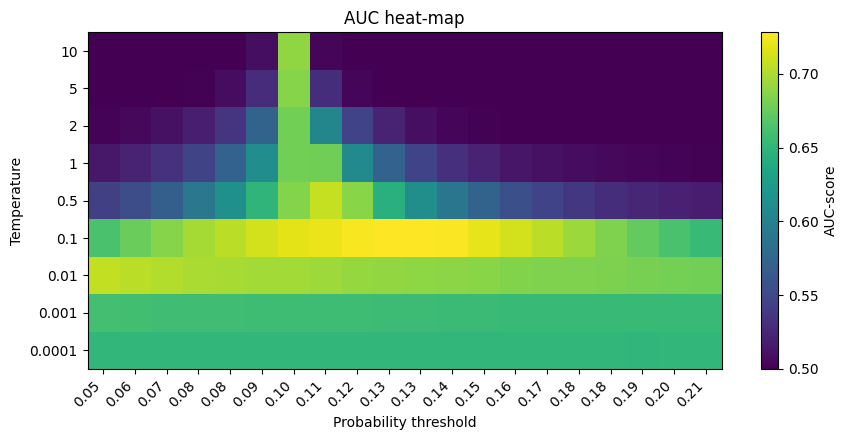

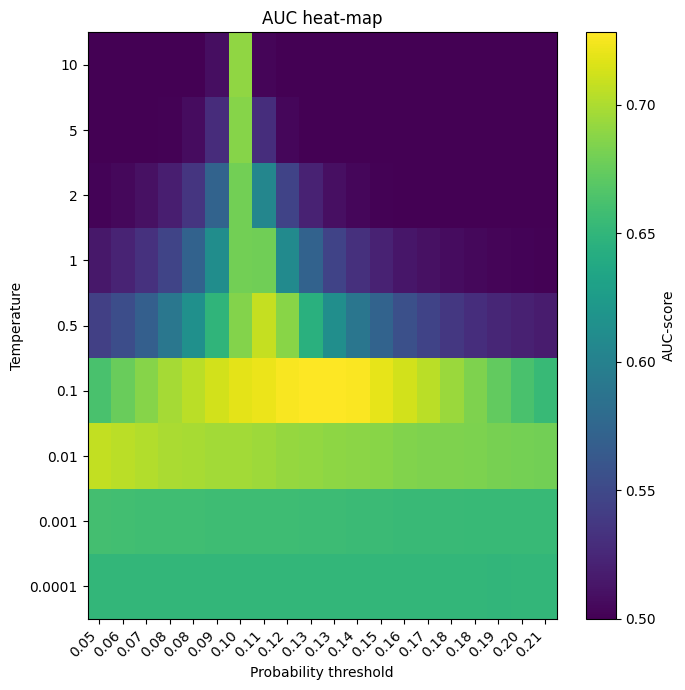

In [15]:
# ------------------------------------------------------------------
# 1.--- Load test labels (first column)
# ------------------------------------------------------------------
test_file = os.path.join(data_path, "test_data_mid")
y_true    = pd.read_csv(test_file, sep='\t', header=None, usecols=[0]).values.ravel()

# ------------------------------------------------------------------
# 2.--- Define grid
# ------------------------------------------------------------------
temperatures = [0.0001, 0.001, 0.01, 0.1, 0.5, 1, 2, 5, 10]          # 9 rows
thresholds   = np.linspace(0.05, 0.21, 20)                           # 10 columns

heat = np.zeros((len(temperatures), len(thresholds)))               # result matrix

# ------------------------------------------------------------------
# 3.--- Loop over T, compute probs once, reuse for all thresholds
# ------------------------------------------------------------------
group_size = 10
model_best_trained.iterator.batch_size = group_size
logit_tensor = model_best_trained.logit          # raw scores

for t_idx, T in enumerate(temperatures):

    all_probs = []
    for batch in model_best_trained.iterator.load_data_from_file(test_file, 0):
        feed_dict = {
            model_best_trained.layer_keeps: [1.0, 1.0],
            model_best_trained.is_train_stage: False,
            model_best_trained.temperature: 1,
            **batch
        }
        logits = sess.run(logit_tensor, feed_dict=feed_dict).ravel()
        probs  = softmax(logits.reshape(-1, group_size) / T, axis=1).ravel()
        all_probs.extend(probs)

    all_probs = np.asarray(all_probs)[:len(y_true)]      # trim just in case

    # ----- evaluate every threshold with the same probs -----
    for c_idx, thr in enumerate(thresholds):
        y_pred = (all_probs >= thr).astype(int)
        heat[t_idx, c_idx] = roc_auc_score(y_true, y_pred)

# ------------------------------------------------------------------
# 4.--- Plot heat-map
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 4.5))
img = ax.imshow(heat, aspect="auto", origin="lower")

# axis ticks / labels
ax.set_xticks(np.arange(len(thresholds)))
ax.set_xticklabels([f"{x:.2f}" for x in thresholds], rotation=45, ha="right")
ax.set_xlabel("Probability threshold")

ax.set_yticks(np.arange(len(temperatures)))
ax.set_yticklabels([str(T) for T in temperatures])
ax.set_ylabel("Temperature")

# colour-bar
cbar = plt.colorbar(img, ax=ax)
cbar.set_label("AUC-score")

ax.set_title("AUC heat-map")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 7))
img = ax.imshow(heat, aspect="auto", origin="lower")

# axis ticks / labels
ax.set_xticks(np.arange(len(thresholds)))
ax.set_xticklabels([f"{x:.2f}" for x in thresholds], rotation=45, ha="right")
ax.set_xlabel("Probability threshold")

ax.set_yticks(np.arange(len(temperatures)))
ax.set_yticklabels([str(T) for T in temperatures])
ax.set_ylabel("Temperature")

# colour-bar
cbar = plt.colorbar(img, ax=ax)
cbar.set_label("AUC-score")

ax.set_title("AUC heat-map")
plt.tight_layout()
plt.show()

Attempting to load the first batch of 10 items...
[0.32315493 0.13540554 0.4055556  0.4329145  0.41548455 0.22762287
 0.28144634 0.24735355 0.41483665 0.16719317]
Successfully retrieved raw logits for the first 10 items.

Calculating probabilities for different temperatures...

Generating visualization...


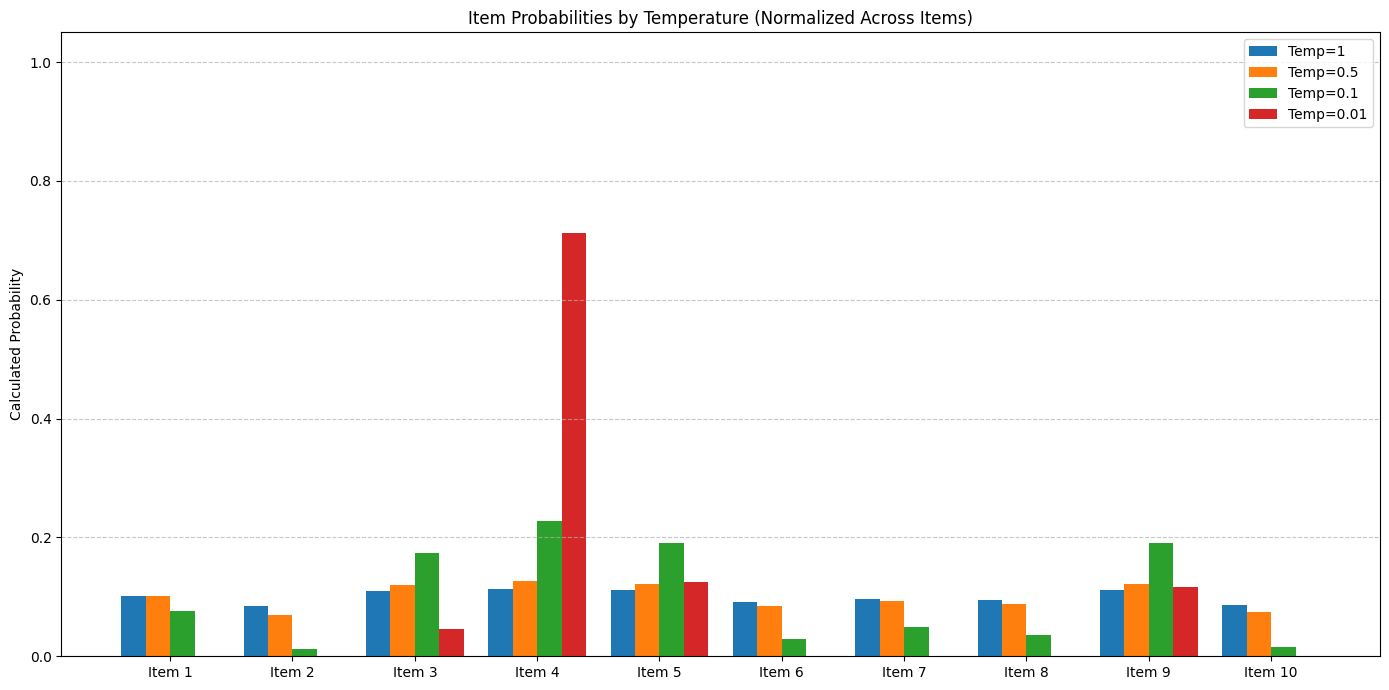


Done.


In [16]:
# --- Configuration ---
temperatures_to_test = [1, 0.5, 0.1, 0.01]
num_items_to_process = 10 # Corresponds to the batch size

# --- Step 1: Get Raw Logits for the First Batch ---

raw_logits = None
model_best_trained.iterator.batch_size = num_items_to_process

print(f"Attempting to load the first batch of {num_items_to_process} items...")

# Load only the first batch
for batch_data in model_best_trained.iterator.load_data_from_file(test_file, batch_num_ngs=0):
    if batch_data:
        # Build the feed dictionary (temperature here doesn't matter as we apply it manually later)
        feed_dict = {}
        feed_dict[model_best_trained.is_train_stage] = False
        feed_dict[model_best_trained.layer_keeps] = [1.0, 1.0]
        feed_dict[model_best_trained.temperature] = 1.0 # Placeholder value
        for key, value in batch_data.items():
            feed_dict[key] = value

        # Run inference once to get the raw scores (logits)
        preds = sess.run(model_best_trained.logit, feed_dict=feed_dict)
        raw_logits = preds.flatten() # Shape becomes (num_items_to_process,)
        print(raw_logits)
        print(f"Successfully retrieved raw logits for the first {len(raw_logits)} items.")
        # print(f"Raw Logits: {raw_logits}") # Optional: print the raw scores
        break # Exit after processing the first batch
    else:
        print("First batch data was empty.")
        break

if raw_logits is None:
    print("Error: Could not retrieve data/logits for the first batch. Cannot proceed.")
    # Exit or handle error appropriately
    exit()
elif len(raw_logits) != num_items_to_process:
    print(f"Warning: Retrieved {len(raw_logits)} items, expected {num_items_to_process}.")
    # Adjust num_items_to_process if needed, or handle error
    num_items_to_process = len(raw_logits)


# --- Step 2: Calculate Probabilities for Different Temperatures ---

probs_by_temp = {} # Dictionary to store {temp: [prob1, prob2, ...]}

print("\nCalculating probabilities for different temperatures...")
for temp in temperatures_to_test:
    # Apply temperature scaling to the *same* raw logits
    # Handle potential division by zero if temp is extremely small
    if abs(temp) < 1e-9:
        print(f"Warning: Temperature {temp} is close to zero. Using a small epsilon instead.")
        temp = 1e-9 * np.sign(temp) if temp != 0 else 1e-9 # Avoid division by zero

    scaled_logits = raw_logits / temp

    # Exponentiate (handle potential overflow with very high scaled_logits)
    # Clipping or alternative stable softmax might be needed for extreme values,
    # but let's try direct exp first.
    exp_preds = np.exp(scaled_logits - np.max(scaled_logits)) # Improve numerical stability by subtracting max

    # Calculate sum for normalization (softmax across the batch items)
    sum_exp = np.sum(exp_preds)

    # Calculate final probabilities
    if sum_exp > 1e-9:
        probs = exp_preds / sum_exp
    else:
        print(f"Warning: Sum of exponentiated predictions is near zero for temp {temp}. Assigning uniform probability.")
        probs = np.ones(num_items_to_process) / num_items_to_process

    probs_by_temp[temp] = probs
    # Optional: print results for verification
    # print(f"  Temp={temp}: Prob Sum={np.sum(probs):.4f}")
    # print(f"    Probs: {np.round(probs, 4)}")


# --- Step 3: Visualize using Grouped Bar Chart ---

print("\nGenerating visualization...")

if not probs_by_temp:
    print("No probabilities were calculated. Cannot generate plot.")
else:
    labels = [f'Item {i+1}' for i in range(num_items_to_process)]
    x = np.arange(len(labels))  # the label locations
    num_temps = len(temperatures_to_test)
    width = 0.8 / num_temps # Adjust bar width based on number of temps
    multiplier = 0

    fig, ax = plt.subplots(figsize=(14, 7)) # Create figure and axes objects

    for temperature, probabilities in probs_by_temp.items():
        offset = width * multiplier
        rects = ax.bar(x + offset, probabilities, width, label=f'Temp={temperature}')
        # Optional: Add labels on top of bars
        # ax.bar_label(rects, padding=3, fmt='%.3f', rotation=90)
        multiplier += 1

    # Add some text for labels, title and axes ticks
    ax.set_ylabel('Calculated Probability')
    ax.set_title('Item Probabilities by Temperature (Normalized Across Items)')
    ax.set_xticks(x + width * (num_temps - 1) / 2) # Center ticks between grouped bars
    ax.set_xticklabels(labels)
    ax.legend(loc='upper right')
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    # Set y-axis limit for probability
    ax.set_ylim(0, 1.05)

    fig.tight_layout() # Adjust layout to prevent labels overlapping
    plt.show()

print("\nDone.")

Evaluating temperatures: [1, 0.5, 0.1, 0.01]
  Temperature 1
    collected 5000 slates
  Temperature 0.5
    collected 5000 slates
  Temperature 0.1
    collected 5000 slates
  Temperature 0.01
    collected 5000 slates


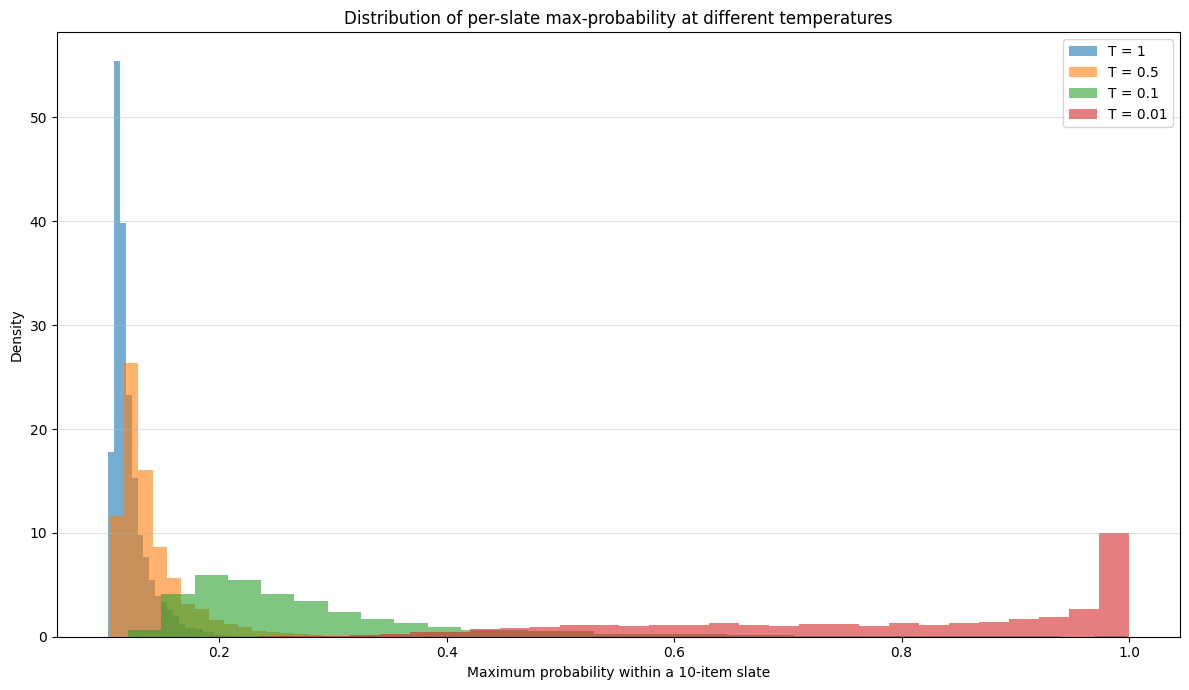

Mean of max-probs at each temperature
T = 1      mean = 0.1206
T = 0.5    mean = 0.1409
T = 0.1    mean = 0.2810
T = 0.01   mean = 0.7885


In [17]:
def evaluate_temperature_effect(model,
                                sess,
                                test_file,
                                temperature_values,
                                group_size=10,
                                max_batches=None,               # None = use full file
                                bins=30):
    """
    Plot the distribution of the *maximum* slate probability for several
    temperature values.

    Parameters
    ----------
    model, sess        : trained DeepRec model and its active TF session
    test_file          : path to .tsv test file
    temperature_values : iterable of temperatures (e.g. [2, 1, 0.1, 0.01])
    group_size         : number of items per slate (10 in your data)
    max_batches        : optional early stop for speed
    bins               : number of histogram bins
    """
    predictions_by_temp = {}

    logit_tensor = model.logit
    model.iterator.batch_size = group_size   # one slate per batch row

    print(f"Evaluating temperatures: {temperature_values}")

    for T in temperature_values:
        print(f"  Temperature {T}")
        max_probs = []
        batch_ctr = 0

        for batch in model.iterator.load_data_from_file(test_file, 0):
            if max_batches is not None and batch_ctr >= max_batches:
                break

            feed_dict = {
                model.layer_keeps:    [1.0, 1.0],
                model.is_train_stage: False,
                model.temperature:    1,         # <-- temperature
                **batch
            }

            logits = sess.run(logit_tensor, feed_dict=feed_dict).ravel()
            probs  = softmax(logits.reshape(-1, group_size) / T, axis=1)
            max_probs.extend(probs.max(axis=1))   # one value per slate

            batch_ctr += 1

        if len(max_probs) == 0:
            print(f"    Warning: no data processed for T={T}.")
            continue

        predictions_by_temp[T] = np.asarray(max_probs)
        print(f"    collected {len(max_probs)} slates")

    # --------------- plot -----------------
    if not predictions_by_temp:
        print("No data collected for any temperature. Nothing to plot.")
        return {}

    plt.figure(figsize=(12, 7))
    for T, vec in predictions_by_temp.items():
        plt.hist(vec,
                 bins=bins,
                 density=True,
                 alpha=0.6,
                 label=f"T = {T}")

    plt.xlabel("Maximum probability within a 10-item slate")
    plt.ylabel("Density")
    plt.title("Distribution of per-slate max-probability at different temperatures")
    plt.legend()
    plt.grid(axis='y', alpha=0.4)
    plt.tight_layout()
    plt.show()

    # ---------- simple summary statistic ----------
    return {T: np.mean(v) for T, v in predictions_by_temp.items()}

temperature_values = [1,0.5, 0.1, 0.01]
eval_results = evaluate_temperature_effect(model_best_trained,
                                           sess,
                                           test_file,
                                           temperature_values)

print("Mean of max-probs at each temperature")
for T, m in eval_results.items():
    print(f"T = {T:<5}  mean = {m:.4f}")